This notebook explores the Fannie Mae MFLPD dataset structure, identify which
columns can serve as model inputs (X) and outputs (y), assess whether this
data supports default prediction for a DFAST stress-testing project, and
determine what feature engineering and class-imbalance handling is needed.

Now includes Historical Annual DSCR File merge with forward-fill
     and staleness counter logic.

Data Sources:
  1. Main File (sample.csv) — Loan-level + monthly performance panel
  2. Historical Annual DSCR File (sample_dscr.csv) — Annual DSCR evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

In [4]:
df = pd.read_csv("../data/sample.csv")
dscr = pd.read_csv("../data/sample_dscr.csv")
 
df["Reporting Period Date"] = pd.to_datetime(df["Reporting Period Date"])
 
print("Main file:")
print(df.shape)
df.head(10)

Main file:
(241, 57)


,Loan Number,Acquisition Date,Note Date,Maturity Date at Acquisition,Loan Acquisition UPB,Amortization Type,Interest Type,Loan Product Type,Original UPB,Amortization Term,Original Interest Rate,Lien Position,Transaction ID,Issue Date,Loan Acquisition LTV,Underwritten DSCR,Underwritten DSCR Type,Original Term,Original I/O Term,I/O End Date,Loan Ever 60+ Days Delinquent,Loss Sharing Type,Modified Loss Sharing Percentage,Number of Properties at Acquisition,Property Acquisition Total Unit Count,Specific Property Type,Year Built,Property City,Property State,Property Zip Code,Metropolitan Statistical Area,Physical Occupancy %,Liquidation/Prepayment Code,Liquidation/Prepayment Date,Foreclosure Date,Credit Event Date,Foreclosure Value,Lifetime Net Credit Loss Amount,Sale Price,Default Amount,Credit Event Type,Reporting Period Date,Loan Active Property Count,Note Rate,Maturity Date - Current,UPB - Current,Delinquency UPB,Loan Payment Status,SDQ Indicator,Most Recent Modification Date,Modification Indicator,Defeasance Date,Prepayment Provision,Prepayment Provision End Date,Affordable Housing Type,MCIRT Deal ID,MCAS Deal ID
0,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-03-01,1,5.11,3/1/2024,900000,0,Current,N,NaN,N,NaN,"YM(114), See Issuance Documents(6)","YM(08/31/2023), See Issuance Documents(03/01/2...",LIHTC & Project Based HAP/Sec 8,MCIRT 2016-01,NaN
1,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-04-01,1,5.11,3/1/2024,900000,0,Current,N,NaN,N,NaN,"YM(114), See Issuance Documents(6)","YM(08/31/2023), See Issuance Documents(03/01/2...",LIHTC & Project Based HAP/Sec 8,MCIRT 2016-01,NaN
2,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-05-01,1,5.11,3/1/2024,900000,0,Current,N,NaN,N,NaN,"YM(114), See Issuance Documents(6)","YM(08/31/2023), See Issuance Documents(03/01/2...",LIHTC & Project Based HAP/Sec 8,MCIRT 2016-01,NaN
3,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-06-01,1,5.11,3/1/2024,900000,0,Current,N,NaN,N,NaN,"YM(114), See Issuance Documents(6)","YM(08/31/2023), See Issuance Documents(03/01/2...",LIHTC & Project Based HAP/Sec 8,MCIRT 2016-01,NaN
4,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-07-01,1,5.11,3/1/2024,900000,0,Current,N,NaN,N,NaN,"YM(114), See Issuance Documents(6)","YM(08/31/2023), See Issuance Documents(03/01/2...",LIHTC & Project Based HAP/Sec 8,MCIRT 2016-01,NaN
5,1111111111,3/31/2014,2/27/2014,3/1/2024,1000000,Amortizing Balloon,Fixed,DUS,1000000,360.0,5.11,First,111111.0,3/1/2014,70,1.35,UW Actual DSCR,120,NaN,NaN,Y,Standard DUS,NaN,1.0,100.0,Multifamily,1995,WASHINGTON,DC,11111,"WASHINGTON-ARLINGTON-ALEXANDRIA, DC-VA-MD-WV M...",95.0,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,2014-08-01,1,5.11,3/1/

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 57 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Loan Number                            241 non-null    int64         
 1   Acquisition Date                       241 non-null    object        
 2   Note Date                              241 non-null    object        
 3   Maturity Date at Acquisition           241 non-null    object        
 4   Loan Acquisition UPB                   241 non-null    int64         
 5   Amortization Type                      181 non-null    object        
 6   Interest Type                          241 non-null    object        
 7   Loan Product Type                      241 non-null    object        
 8   Original UPB                           241 non-null    int64         
 9   Amortization Term                      181 non-null    float64   

In [6]:
print("DSCR file:")
print(dscr.shape)
dscr.sort_values(["Loan Number", "Year"])

DSCR file:
(17, 3)


,Loan Number,Year,Year DSCR
0,1111111111,2014,1.59
1,1111111111,2016,1.78
3,2222222222,2018,1.86
2,2222222222,2019,1.75
4,2222222222,2020,2.68
6,3333333333,2009,1.25
5,3333333333,2010,1.13
7,3333333333,2011,1.19
13,3333333333,2012,1.25
10,3333333333,2013,1.25


 ## Data Structure

 **Main File**: Panel / longitudinal data. Each row = one loan in one monthly
 reporting period. A loan with 48 months of history has 48 rows. Most columns
 are static (set at acquisition) — only 4 columns change month to month:
 Reporting Period Date, Loan Payment Status, Delinquency UPB, SDQ Indicator.

 **DSCR File**: Annual debt service coverage ratio assessments. NOT every year
 has a DSCR — assessments are periodic. Gaps must be forward-filled.

 **Important**: This is comma-delimited (not pipe), and it's a single file
 (not separate acquisition + performance files like Single Family data).

In [7]:
numeric_cols = [
    "Loan Acquisition UPB", "Original UPB", "Loan Acquisition LTV",
    "Underwritten DSCR", "Original Interest Rate", "Original Term",
    "Amortization Term", "Physical Occupancy %", "Note Rate",
    "UPB - Current", "Property Acquisition Total Unit Count"
]
 
df[numeric_cols].describe()

,Loan Acquisition UPB,Original UPB,Loan Acquisition LTV,Underwritten DSCR,Original Interest Rate,Original Term,Amortization Term,Physical Occupancy %,Note Rate,UPB - Current,Property Acquisition Total Unit Count
count,241.0,241.0,241.0,241.00,2.410000e+02,241.000000,181.000000,241.000000,2.410000e+02,241.0,229.0
mean,1000000.0,1000000.0,70.0,1.35,5.110000e+00,135.186722,440.220994,90.846473,5.110000e+00,900000.0,100.0
std,0.0,0.0,0.0,0.00,8.900269e-16,49.833749,56.646622,20.843536,8.900269e-16,0.0,0.0
min,1000000.0,1000000.0,70.0,1.35,5.110000e+00,60.000000,360.000000,0.000000,5.110000e+00,900000.0,100.0
25%,1000000.0,1000000.0,70.0,1.35,5.110000e+00,120.000000,360.000000,95.300000,5.110000e+00,900000.0,100.0
50%,1000000.0,1000000.0,70.0,1.35,5.110000e+00,180.000000,480.000000,96.000000,5.110000e+00,900000.0,100.0
75%,1000000.0,1000000.0,70.0,1.35,5.110000e+00,180.000000,480.000000,96.000000,5.110000e+00,900000.0,100.0
max,1000000.0,1000000.0,70.0,1.35,5.110000e+00,180.000000,480.000000,96.000000,5.110000e+00,900000.0,100.0


In [8]:
loan_counts = df.groupby("Loan Number").agg(
    rows=("Reporting Period Date", "count"),
    first_date=("Reporting Period Date", "min"),
    last_date=("Reporting Period Date", "max"),
).reset_index()
 
loan_counts

,Loan Number,rows,first_date,last_date
0,1111111111,48,2014-03-01,2018-02-01
1,2222222222,12,2018-01-01,2018-12-01
2,3333333333,60,2004-11-01,2009-10-01
3,4444444444,121,2008-12-01,2018-12-01


In [9]:
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
 
print(f"Columns with nulls ({len(null_pct)} of {len(df.columns)}):\n")
print(null_pct.to_string())

Columns with nulls (22 of 57):

Defeasance Date                          100.0
Foreclosure Date                         100.0
Default Amount                           100.0
Most Recent Modification Date            100.0
Credit Event Date                         99.6
Credit Event Type                         99.6
Lifetime Net Credit Loss Amount           99.6
Liquidation/Prepayment Code               99.2
Liquidation/Prepayment Date               99.2
Original I/O Term                         95.0
MCIRT Deal ID                             80.1
I/O End Date                              70.1
Modified Loss Sharing Percentage          70.1
 Affordable Housing Type                  50.2
MCAS Deal ID                              49.8
Issue Date                                24.9
Amortization Type                         24.9
Amortization Term                         24.9
Transaction ID                            24.9
Prepayment Provision End Date             24.9
Number of Properties at Acqu

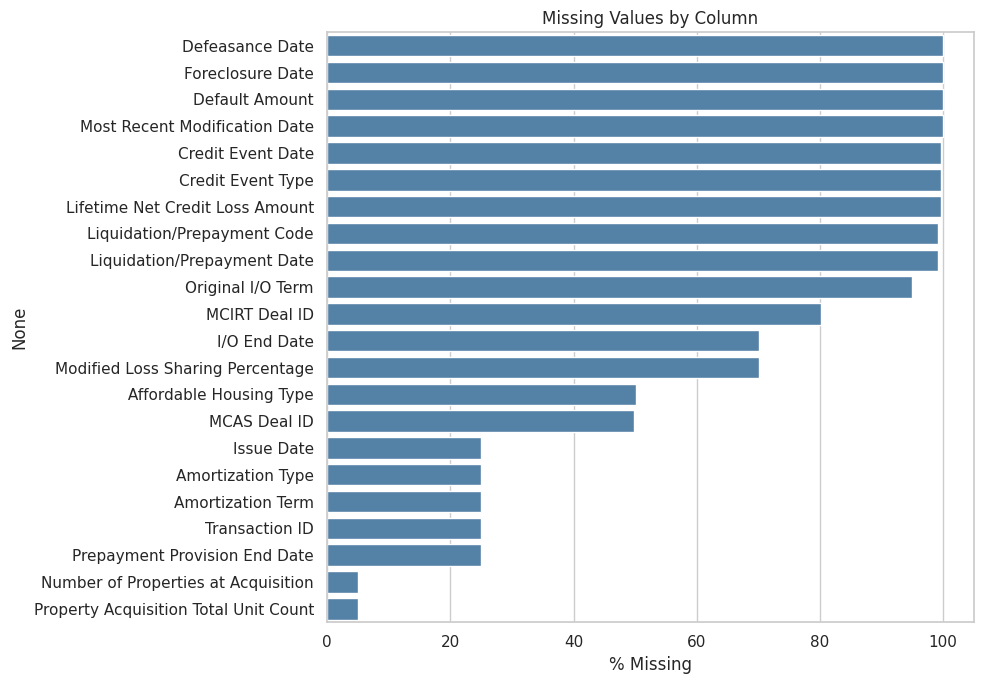

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=null_pct.values, y=null_pct.index, color="steelblue", ax=ax)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()
# Most of the heavily-null columns (Foreclosure Date, Default Amount, Credit
# Event, etc.) are POST-DEFAULT fields we won't use as inputs anyway.
# The features we care about (LTV, DSCR, Rate, UPB, Term) have zero nulls. 

In [11]:
# A column is "time-varying" if it takes different values within a single loan
varies = df.groupby("Loan Number").nunique().max()
time_varying = varies[varies > 1].index.tolist()
static = varies[varies <= 1].index.tolist()
 
print(f"Time-varying columns ({len(time_varying)}):")
for c in time_varying:
    print(f"  {c}")
 
print(f"\nStatic columns: {len(static)}")
 
# Only 4 columns actually change over time. Everything else repeats.

Time-varying columns (4):
  Reporting Period Date
  Delinquency UPB
  Loan Payment Status
  SDQ Indicator

Static columns: 52


In [12]:
df["Loan Payment Status"].value_counts()

Loan Payment Status
Current                  231
90+ Days Delinquent        8
30-59 Days Delinquent      1
60-89 Days Delinquent      1
Name: count, dtype: int64

In [13]:
# For DFAST, default = loan ever reaches 90+ Days Delinquent
ever_default = df.groupby("Loan Number")["Loan Payment Status"].apply(
    lambda x: int((x == "90+ Days Delinquent").any())
)
 
print("Loan-level defaults (D90):")
print(ever_default)
print(f"\nDefault rate: {ever_default.mean():.1%}")

Loan-level defaults (D90):
Loan Number
1111111111    1
2222222222    0
3333333333    0
4444444444    0
Name: Loan Payment Status, dtype: int64

Default rate: 25.0%


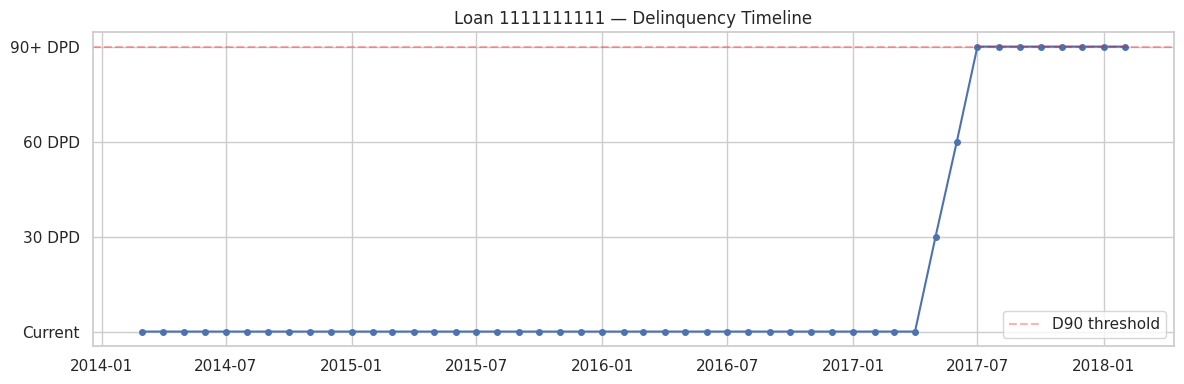

In [14]:
status_map = {"Current": 0, "30-59 Days Delinquent": 1,
              "60-89 Days Delinquent": 2, "90+ Days Delinquent": 3}
 
loan1 = df[df["Loan Number"] == 1111111111].copy().sort_values("Reporting Period Date")
loan1["status_num"] = loan1["Loan Payment Status"].map(status_map)
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(loan1["Reporting Period Date"], loan1["status_num"], marker="o", markersize=4)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["Current", "30 DPD", "60 DPD", "90+ DPD"])
ax.axhline(y=3, color="red", linestyle="--", alpha=0.3, label="D90 threshold")
ax.set_title("Loan 1111111111 — Delinquency Timeline")
ax.legend()
plt.tight_layout()
plt.show()
 
# Classic pattern: Current → 30 → 60 → 90+ and stays there.

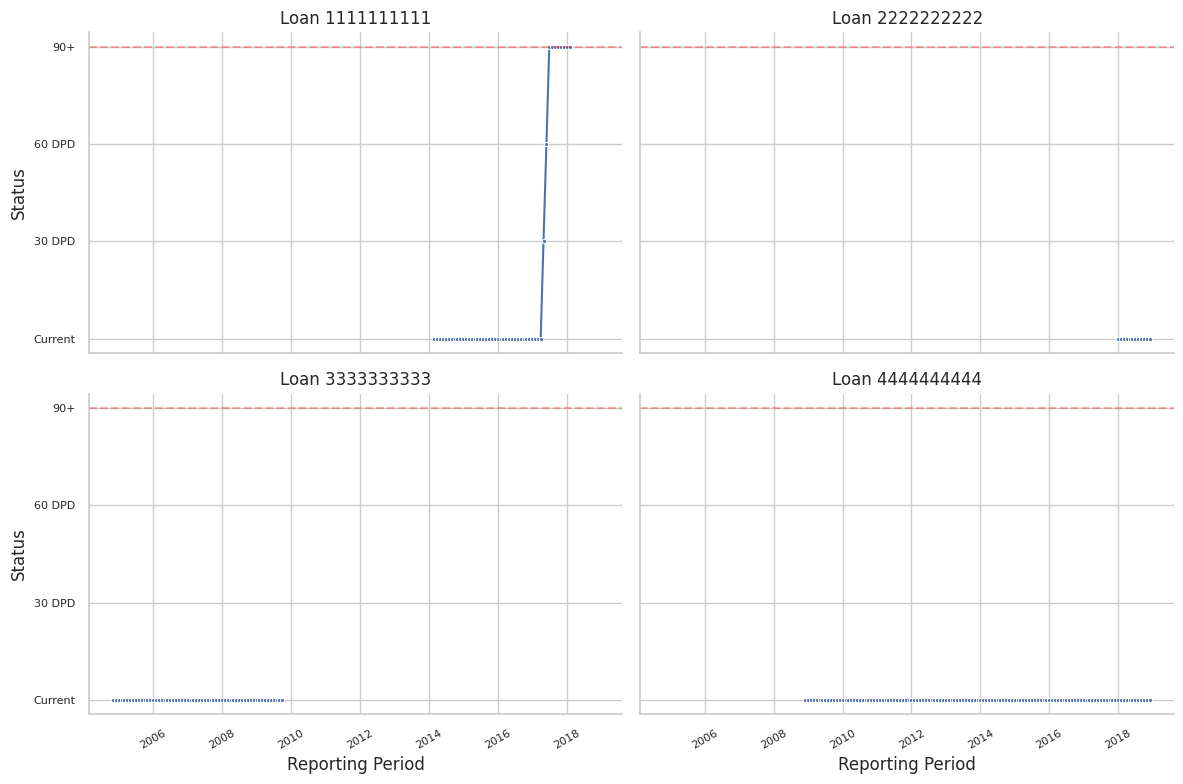

In [15]:
df["status_num"] = df["Loan Payment Status"].map(status_map)
 
g = sns.FacetGrid(df, col="Loan Number", col_wrap=2, height=4, aspect=1.5)
g.map_dataframe(sns.lineplot, x="Reporting Period Date", y="status_num", marker=".")
for ax in g.axes.flat:
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["Current", "30 DPD", "60 DPD", "90+"], fontsize=8)
    ax.axhline(y=3, color="red", linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
g.set_titles("Loan {col_name}")
g.set_axis_labels("Reporting Period", "Status")
plt.tight_layout()
plt.show()
 
# Only Loan 1111111111 ever goes delinquent.

In [16]:
cat_cols = ["Specific Property Type", "Property State", "Interest Type",
            "Loan Product Type", "Loss Sharing Type"]
 
# Look at loan-level (not row-level) to avoid overcounting
loan_cats = df.groupby("Loan Number")[cat_cols].first()
 
for col in cat_cols:
    print(f"\n{col}:")
    print(loan_cats[col].value_counts().to_string())


Specific Property Type:
Specific Property Type
Multifamily            2
Multiple Properties    1
Cooperative            1

Property State:
Property State
DC                     1
Multiple Properties    1
MO                     1
NY                     1

Interest Type:
Interest Type
Fixed    3
ARM      1

Loan Product Type:
Loan Product Type
DUS                1
Credit Facility    1
Bulk Delivery      1
Non-DUS            1

Loss Sharing Type:
Loss Sharing Type
Pari Passu                2
Standard DUS              1
No Lender Loss Sharing    1


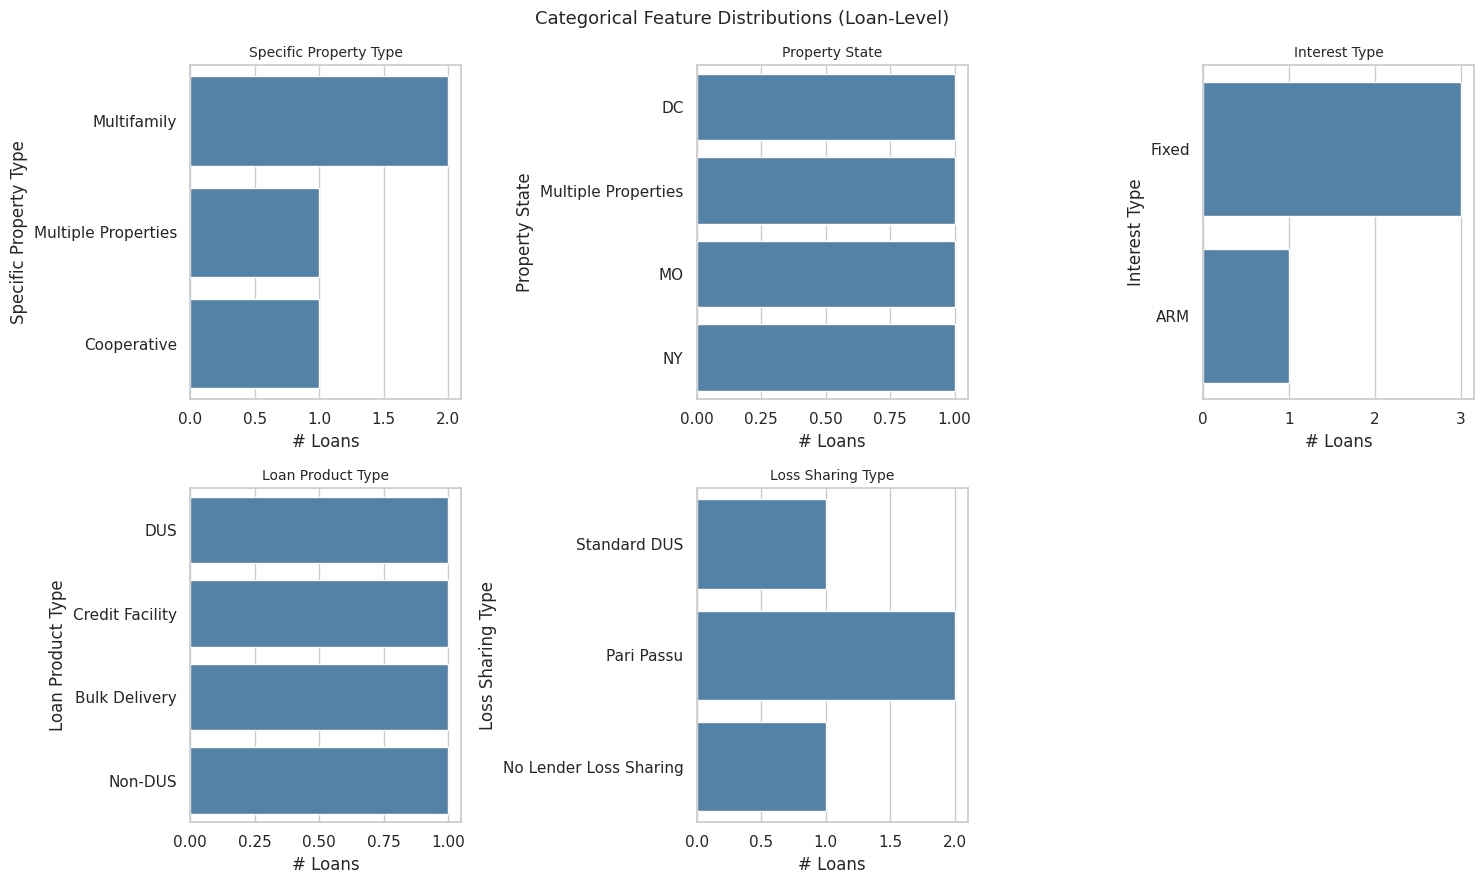

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    sns.countplot(data=loan_cats, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("# Loans")
 
axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Distributions (Loan-Level)", fontsize=13)
plt.tight_layout()
plt.show()

 ## DSCR Merge Strategy

 The DSCR file has annual assessments, but not every year. The plan:

 1. **Join** DSCR to main file on Loan Number + year of Reporting Period
 2. **Forward-fill** gaps: carry the most recent DSCR value forward
 3. **Staleness counter** (`months_since_dscr`): 0 for months within an
    assessment year, then counts up by 1 each month after that year ends.
    Resets to 0 when a new assessment year is reached.

In [18]:
for loan_id in sorted(df["Loan Number"].unique()):
    perf_dates = df[df["Loan Number"] == loan_id]["Reporting Period Date"]
    perf_years = set(range(perf_dates.min().year, perf_dates.max().year + 1))
    dscr_years = set(dscr[dscr["Loan Number"] == loan_id]["Year"].tolist())
    gaps = sorted(perf_years - dscr_years)
 
    print(f"Loan {loan_id}:")
    print(f"  Perf: {perf_dates.min().strftime('%Y-%m')} to {perf_dates.max().strftime('%Y-%m')}")
    print(f"  DSCR years: {sorted(dscr_years)}")
    print(f"  Gaps: {gaps}\n")

Loan 1111111111:
  Perf: 2014-03 to 2018-02
  DSCR years: [2014, 2016]
  Gaps: [2015, 2017, 2018]

Loan 2222222222:
  Perf: 2018-01 to 2018-12
  DSCR years: [2018, 2019, 2020]
  Gaps: []

Loan 3333333333:
  Perf: 2004-11 to 2009-10
  DSCR years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
  Gaps: [2004, 2005, 2006, 2007, 2008]

Loan 4444444444:
  Perf: 2008-12 to 2018-12
  DSCR years: [2007, 2008]
  Gaps: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]



In [19]:
def merge_dscr(main_df, dscr_df):
    """Merge DSCR into main file with forward-fill and staleness counter."""
    merged = main_df.copy()
    merged["reporting_year"] = merged["Reporting Period Date"].dt.year
 
    # Join on Loan Number + year
    dscr_lookup = dscr_df.rename(columns={"Year": "reporting_year"})
    merged = merged.merge(dscr_lookup, on=["Loan Number", "reporting_year"], how="left")
    merged = merged.sort_values(["Loan Number", "Reporting Period Date"])
 
    # Track which year each DSCR came from
    merged["dscr_year"] = merged["reporting_year"].where(merged["Year DSCR"].notna())
 
    # Forward-fill DSCR and assessment year within each loan
    merged["Year DSCR"] = merged.groupby("Loan Number")["Year DSCR"].ffill()
    merged["dscr_year"] = merged.groupby("Loan Number")["dscr_year"].ffill()
 
    # Staleness: 0 if reporting year == assessment year,
    # otherwise months since Jan 1 of (assessment year + 1)
    def staleness(row):
        if pd.isna(row["dscr_year"]):
            return np.nan
        assess_yr = int(row["dscr_year"])
        rpt = row["Reporting Period Date"]
        if rpt.year <= assess_yr:
            return 0
        stale_start = pd.Timestamp(year=assess_yr + 1, month=1, day=1)
        return (rpt.year - stale_start.year) * 12 + (rpt.month - stale_start.month) + 1
 
    merged["months_since_dscr"] = merged.apply(staleness, axis=1)
    merged = merged.drop(columns=["dscr_year", "reporting_year"])
 
    return merged
 
df_merged = merge_dscr(df, dscr)
print(f"Merged shape: {df_merged.shape}")
print(f"New columns: Year DSCR, months_since_dscr")

Merged shape: (241, 60)
New columns: Year DSCR, months_since_dscr


In [20]:
# DSCR assessments: 2014 → 1.59, 2016 → 1.78
# Performance: 2014-03 to 2018-02
#
# Expected:
#   2014 rows:  DSCR=1.59, staleness=0
#   2015 rows:  DSCR=1.59, staleness=1..12
#   2016 rows:  DSCR=1.78, staleness=0
#   2017 rows:  DSCR=1.78, staleness=1..12
#   2018-01:    DSCR=1.78, staleness=13
#   2018-02:    DSCR=1.78, staleness=14
 
cols = ["Reporting Period Date", "Year DSCR", "months_since_dscr", "Loan Payment Status"]
df_merged[df_merged["Loan Number"] == 1111111111][cols].sort_values("Reporting Period Date")

,Reporting Period Date,Year DSCR,months_since_dscr,Loan Payment Status
0,2014-03-01,1.59,0.0,Current
1,2014-04-01,1.59,0.0,Current
2,2014-05-01,1.59,0.0,Current
3,2014-06-01,1.59,0.0,Current
4,2014-07-01,1.59,0.0,Current
5,2014-08-01,1.59,0.0,Current
6,2014-09-01,1.59,0.0,Current
7,2014-10-01,1.59,0.0,Current
8,2014-11-01,1.59,0.0,Current
9,2014-12-01,1.59,0.0,Current


In [21]:
row_check = df_merged[
    (df_merged["Loan Number"] == 1111111111) &
    (df_merged["Reporting Period Date"] == "2018-01-01")
][["Reporting Period Date", "Year DSCR", "months_since_dscr"]]
 
print("Loan 1111111111 on 1/1/2018:")
print(row_check.to_string(index=False))
print("\nExpected: DSCR=1.78, months_since_dscr=13")

Loan 1111111111 on 1/1/2018:
Reporting Period Date  Year DSCR  months_since_dscr
           2018-01-01       1.78               13.0

Expected: DSCR=1.78, months_since_dscr=13


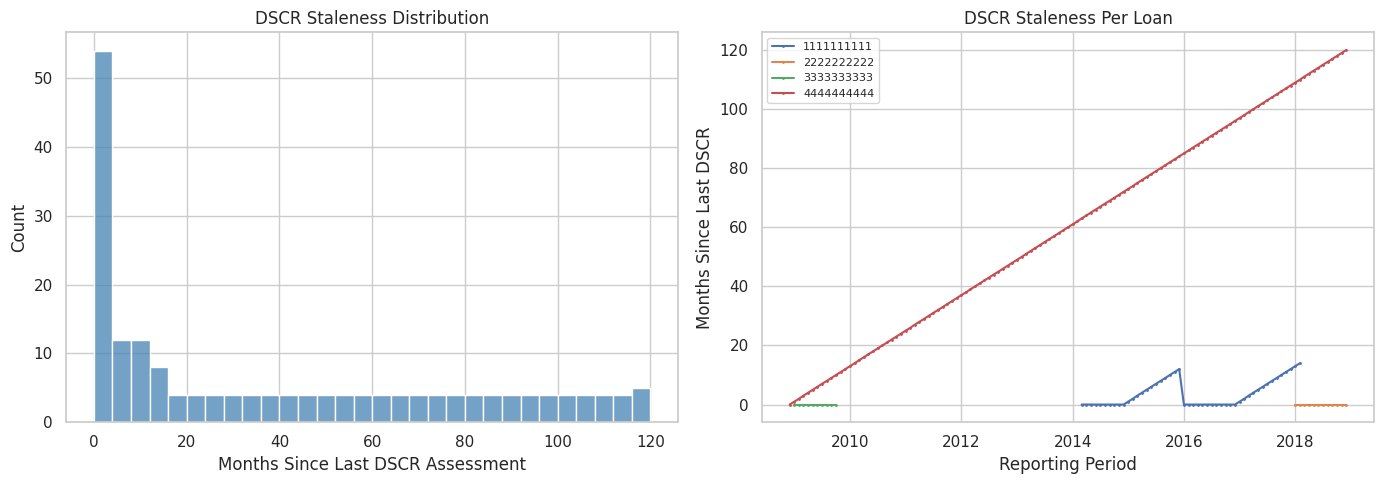

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: histogram of staleness
stale = df_merged["months_since_dscr"].dropna()
sns.histplot(stale, bins=30, ax=axes[0], color="steelblue")
axes[0].set_xlabel("Months Since Last DSCR Assessment")
axes[0].set_title("DSCR Staleness Distribution")
 
# Right: staleness per loan over time
for loan_id in sorted(df_merged["Loan Number"].unique()):
    ld = df_merged[df_merged["Loan Number"] == loan_id].dropna(subset=["months_since_dscr"])
    axes[1].plot(ld["Reporting Period Date"], ld["months_since_dscr"],
                 marker=".", markersize=2, label=f"{loan_id}")
 
axes[1].set_xlabel("Reporting Period")
axes[1].set_ylabel("Months Since Last DSCR")
axes[1].set_title("DSCR Staleness Per Loan")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
 
# Loan 4444444444 has 120+ months of stale DSCR — last assessment was 2008
# but performance data goes through 2018. That's a real risk signal.

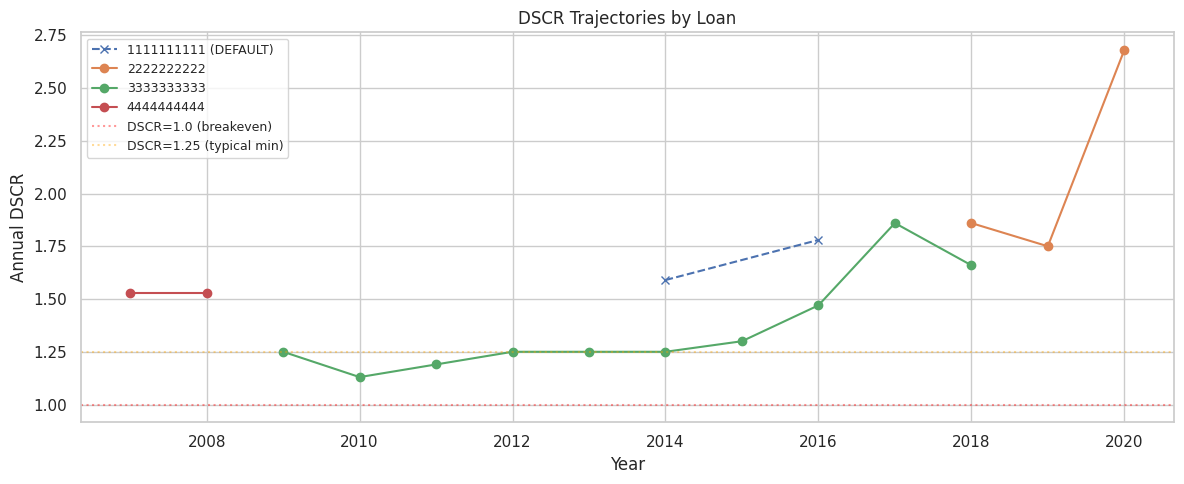

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
 
for loan_id in sorted(dscr["Loan Number"].unique()):
    ld = dscr[dscr["Loan Number"] == loan_id].sort_values("Year")
    defaulted = ever_default.get(loan_id, 0)
    style = "--" if defaulted else "-"
    marker = "x" if defaulted else "o"
    label = f"{loan_id} (DEFAULT)" if defaulted else str(loan_id)
    ax.plot(ld["Year"], ld["Year DSCR"], marker=marker, linestyle=style, label=label)
 
ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.4, label="DSCR=1.0 (breakeven)")
ax.axhline(y=1.25, color="orange", linestyle=":", alpha=0.4, label="DSCR=1.25 (typical min)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual DSCR")
ax.set_title("DSCR Trajectories by Loan")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
 
# Interesting: the defaulting loan actually had IMPROVING DSCR (1.59 → 1.78)
# right before going 90+ DPD. DSCR alone doesn't predict default — that's
# exactly why we need the macro scenario overlay for DFAST.

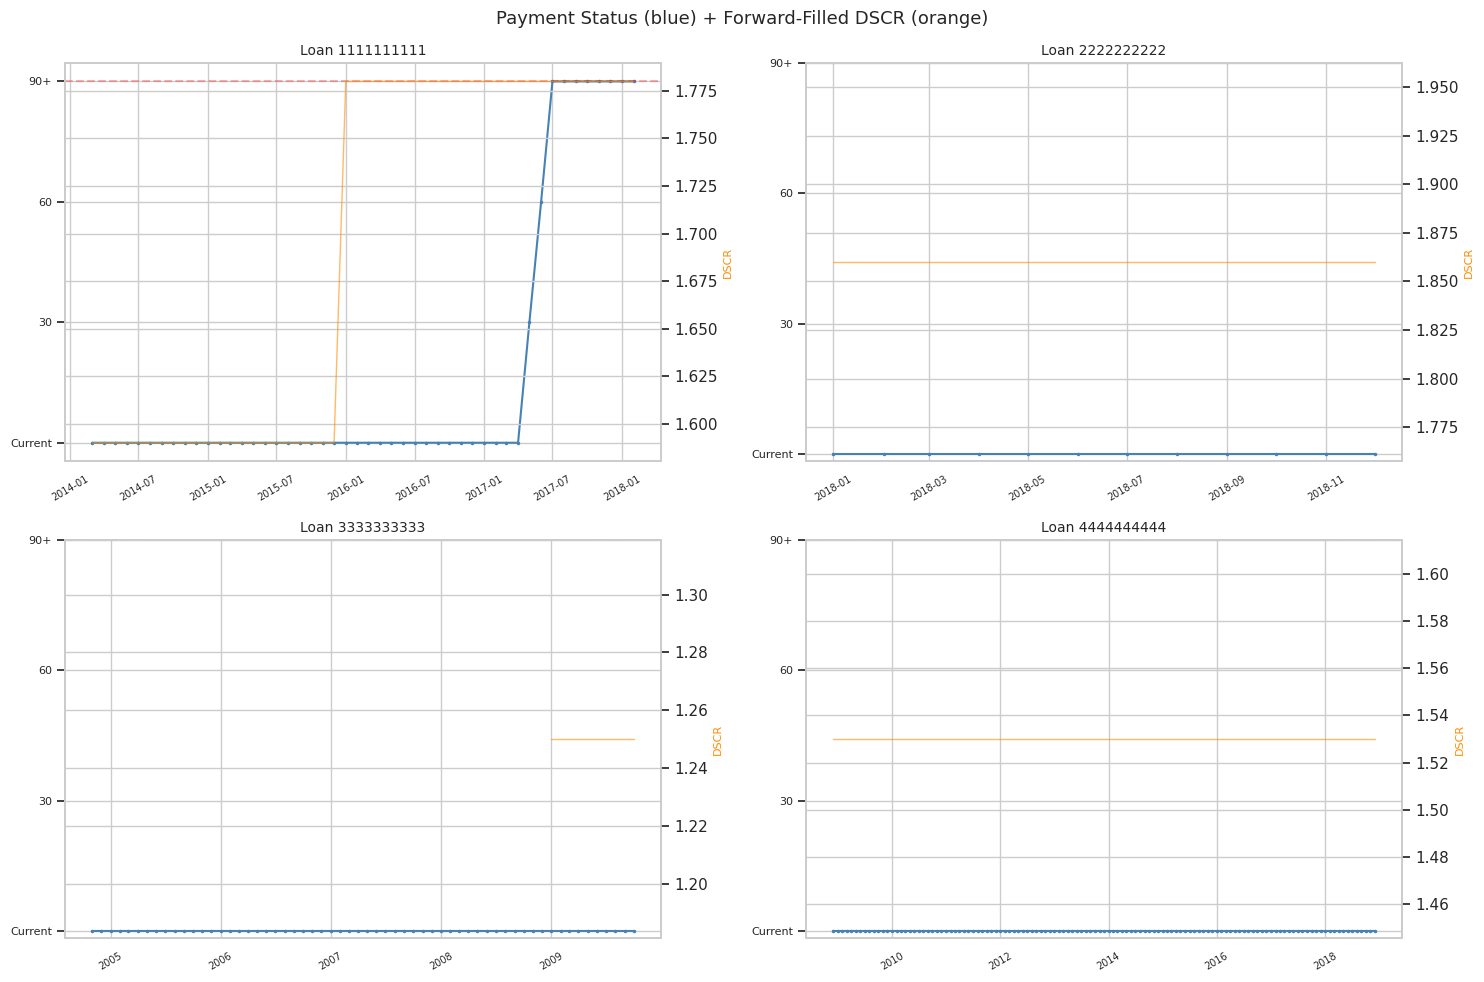

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
 
for i, loan_id in enumerate(sorted(df_merged["Loan Number"].unique())):
    ax = axes[i]
    ld = df_merged[df_merged["Loan Number"] == loan_id].sort_values("Reporting Period Date")
 
    ax.plot(ld["Reporting Period Date"], ld["status_num"], marker=".", markersize=3, color="steelblue")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["Current", "30", "60", "90+"], fontsize=8)
    ax.axhline(y=3, color="red", linestyle="--", alpha=0.3)
 
    # DSCR on secondary axis
    ax2 = ax.twinx()
    dscr_data = ld[["Reporting Period Date", "Year DSCR"]].dropna()
    if len(dscr_data) > 0:
        ax2.plot(dscr_data["Reporting Period Date"], dscr_data["Year DSCR"],
                 color="darkorange", alpha=0.6, linewidth=1)
        ax2.set_ylabel("DSCR", color="darkorange", fontsize=8)
 
    ax.set_title(f"Loan {loan_id}", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
 
plt.suptitle("Payment Status (blue) + Forward-Filled DSCR (orange)", fontsize=13)
plt.tight_layout()
plt.show()

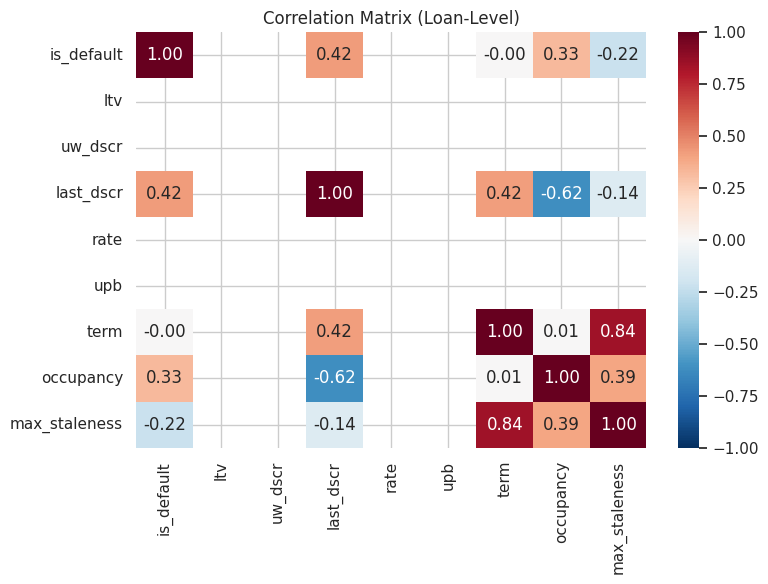

In [25]:
loan_level = df_merged.groupby("Loan Number").agg(
    is_default=("Loan Payment Status", lambda x: int((x == "90+ Days Delinquent").any())),
    ltv=("Loan Acquisition LTV", "first"),
    uw_dscr=("Underwritten DSCR", "first"),
    last_dscr=("Year DSCR", "last"),
    rate=("Original Interest Rate", "first"),
    upb=("Original UPB", "first"),
    term=("Original Term", "first"),
    occupancy=("Physical Occupancy %", "first"),
    max_staleness=("months_since_dscr", "max"),
).reset_index()
 
fig, ax = plt.subplots(figsize=(8, 6))
corr = loan_level.drop(columns=["Loan Number"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix (Loan-Level)")
plt.tight_layout()
plt.show()
 
# With only 4 loans these correlations aren't meaningful. The full dataset
# with thousands of loans will show real patterns.

In [26]:
loan_segs = df.groupby("Loan Number").agg(
    default=("Loan Payment Status", lambda x: int((x == "90+ Days Delinquent").any())),
    property_type=("Specific Property Type", "first"),
    state=("Property State", "first"),
    product_type=("Loan Product Type", "first"),
    interest_type=("Interest Type", "first"),
)
 
for col in ["property_type", "state", "product_type", "interest_type"]:
    print(f"\nDefault rate by {col}:")
    print(loan_segs.groupby(col)["default"].agg(["count", "sum", "mean"]).rename(
        columns={"count": "loans", "sum": "defaults", "mean": "default_rate"}
    ))


Default rate by property_type:
                     loans  defaults  default_rate
property_type                                     
Cooperative              1         0           0.0
Multifamily              2         1           0.5
Multiple Properties      1         0           0.0

Default rate by state:
                     loans  defaults  default_rate
state                                             
DC                       1         1           1.0
MO                       1         0           0.0
Multiple Properties      1         0           0.0
NY                       1         0           0.0

Default rate by product_type:
                 loans  defaults  default_rate
product_type                                  
Bulk Delivery        1         0           0.0
Credit Facility      1         0           0.0
DUS                  1         1           1.0
Non-DUS              1         0           0.0

Default rate by interest_type:
               loans  defaults  defaul

 ## Feature Classification

 ### Target (y)
 `is_default` = 1 if loan ever reaches "90+ Days Delinquent" (D90 standard)

 ### Inputs (X) — Direct from main file (14 static columns)
 | Feature | Column | Why |
 |---------|--------|-----|
 | Loan Acquisition LTV | 15 | Leverage — #1 credit risk predictor |
 | Underwritten DSCR | 16 | Cash flow coverage at origination |
 | Original Interest Rate | 11 | Payment burden |
 | Original UPB | 9 | Loan size |
 | Original Term | 18 | Duration |
 | Amortization Term | 10 | Payment size |
 | Physical Occupancy % | 32 | Income stability |
 | Unit Count | 25 | Property size |
 | Specific Property Type | 26 | Multifamily / Coop / MHC |
 | Property State | 29 | Geographic risk (→ region) |
 | Interest Type | 7 | Fixed vs ARM |
 | Amortization Type | 6 | Balloon / IO risk |
 | Loan Product Type | 8 | DUS / Non-DUS |
 | Loss Sharing Type | 22 | Risk allocation |

 ### Inputs (X) — From DSCR file (2 columns)
 | Feature | Notes |
 |---------|-------|
 | Year DSCR | Forward-filled annual DSCR. Current cash flow health. |
 | months_since_dscr | Staleness counter. High = more uncertainty. |

 ### Inputs (X) — Engineered (5 features)
 | Feature | Logic |
 |---------|-------|
 | loan_age | Months from Note Date to observation |
 | current_ltv | Acquisition LTV / (1 + hpi_change) — stressed |
 | region | State → 4 Census regions |
 | is_interest_only | 1 if Amort Type contains "Interest Only" |
 | dscr_change | Year DSCR - Underwritten DSCR (trajectory) |

 ### Inputs (X) — Macro overlay (3 synthetic features)
 | Feature | Scenario shocked |
 |---------|-----------------|
 | unemployment_rate | Baseline 4.5%, Adverse 7%, Severe 10% |
 | gdp_growth | Baseline +2%, Adverse -2%, Severe -6% |
 | hpi_change | Baseline 0%, Adverse -15%, Severe -30% |

 ### Excluded — Target leakage
 Loan Payment Status, SDQ Indicator, Loan Ever 60+ DQ, Delinquency UPB,
 Default Amount, Foreclosure Date/Value, Credit Event Date/Type,
 Lifetime Net Credit Loss, Sale Price, Liquidation/Prepayment Code/Date

 ### Excluded — Not useful
 Loan Number, Transaction ID, Issue Date, Reporting Period Date,
 Modification Indicator, Defeasance Date, Prepayment Provision,
 MCIRT/MCAS Deal ID, Property City/Zip/MSA, Year Built

## Class Imbalance Strategy

In this 4-loan sample the default rate is 25%, but in the full dataset
it'll be 1-5%. That's severe class imbalance.

**Recommended approach** (best for regulated environment):
- **Class weights**: `class_weight='balanced'` (LR), `scale_pos_weight` (XGBoost)
- **Stratified splits**: `stratify=y` in train_test_split
- **Threshold tuning**: optimize cutoff via Youden's J, not default 0.5

**Not using SMOTE**: Creates synthetic minority samples that are hard to
defend under SR 11-7 model risk management. Class weights are simpler
and more transparent — same rebalancing effect without synthetic data.

## Feature Engineering Plan

**From existing columns:**
1. `loan_age` — months between Note Date and observation
2. `current_ltv` — Acquisition LTV / (1 + hpi_change) — core DFAST feature
3. `region` — State mapped to Northeast / Southeast / Midwest / West
4. `is_interest_only` — 1 if Amortization Type contains "Interest Only"
5. `dscr_change` — Year DSCR minus Underwritten DSCR (positive = improving)
6. `months_since_dscr` — already computed in merge

**Macro features (synthetic, for DFAST overlay):**
7. unemployment_rate
8. gdp_growth
9. hpi_change → feeds into current_ltv calculation

**Total**: ~24 features → binary target

## Final Assessment

**Verdict: YES** — this data supports DFAST default prediction.

**Data corrections** from our original assumptions:
- Comma-delimited (not pipe-delimited)
- Single main file (not separate acq + perf files)
- Panel data with static + time-varying fields mixed in same rows
- Separate DSCR file joined on Loan Number + Year, forward-filled

**Feature summary**: 14 direct + 2 from DSCR + 5 engineered + 3 macro = ~24 features

**Class imbalance**: class weights + stratified splits (no SMOTE)